# Behavioral Determinants of Student Mental Health: An Explanatory Regression Analysis

## Transition to Regression Modeling

The statistical analysis identified strong linear associations between students’ mental health scores and key behavioral variables, particularly daily social media usage and sleep duration. In contrast, categorical demographic factors demonstrated limited explanatory power and small practical effect sizes.

While correlation analysis provided important evidence of pairwise relationships, it does not capture the joint contribution of multiple predictors nor does it allow assessment of conditional effects when variables are considered simultaneously.

Therefore, the next stage of the analysis moves from statistical association to explanatory modeling using linear regression. The goal is not merely to maximize predictive performance, but to evaluate whether behavioral variables retain their explanatory power when modeled together and to assess the adequacy of a linear functional form.

Importantly, the addiction score variable—despite its extremely strong correlation with mental health—will initially be excluded from the baseline model. This decision is motivated by the potential conceptual overlap between addiction and mental health constructs, which may inflate explanatory power without providing independent behavioral insight.

The modeling stage thus focuses first on behavioral intensity variables (usage and sleep) as primary explanatory factors.

## Modeling Objective

The objective of this modeling stage is to:

Quantify the joint explanatory contribution of daily social media usage and sleep duration to mental health scores;

Assess the adequacy of a linear regression framework;

Evaluate model performance using out-of-sample validation;

Analyze residual structure to detect potential model misspecification;

Compare explanatory strength before and after inclusion of the addiction score.

## Modeling Hypotheses

Based on the statistical analysis, the following assumptions are formulated:

Higher daily social media usage is associated with lower mental health scores (negative coefficient expected).

Longer sleep duration is associated with higher mental health scores (positive coefficient expected).

The linear regression model will explain a substantial proportion of variance in mental health, though likely lower than models including addiction score.

The explanatory power of usage may decrease after inclusion of addiction score due to conceptual overlap.

## Expected Outcomes

It is expected that:

The baseline behavioral model will demonstrate meaningful explanatory power.

Coefficient signs will align with correlation findings.

Residual diagnostics will help evaluate the suitability of the linear assumption.

Inclusion of addiction score in a later stage will significantly increase model fit, potentially revealing multicollinearity and conceptual redundancy.

In [20]:
# Core libraries
import warnings

import pandas as pd
import numpy as np

from scipy import stats

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns


# -------------------------------
# - Warnings / Notebook hygiene -
# -------------------------------

warnings.filterwarnings("ignore") # убирает шум

# ---------------------------
# - Pandas display settings -
# ---------------------------

# Show all columns in DataFrame output
pd.set_option("display.max_columns", None)

# Show maximum column width
pd.set_option("display.max_colwidth", 150)

# Set maximum number of rows
pd.set_option("display.max_rows", 60) 

# Format float numbers
pd.set_option("display.float_format", "{:.2f}".format)

# --------------------
# - Seaborn settings -
# --------------------

# Set overall seaborn theme
sns.set_theme(
  style="whitegrid",
  context="notebook"
)

# -------------------------------
# - Matplotlib default settings -
# -------------------------------

# Set default figure size
plt.rcParams["figure.figsize"]=(10, 6)

# Improve layout so lables don't overlap
plt.rcParams["figure.autolayout"] = True

# DPI for saved images
plt.rcParams["savefig.dpi"] = 150

# --------------------
# - Dataset cleaning -
# --------------------

df = pd.read_csv("../data/Students Social Media Addiction.csv")

df.head()

df.sample(8)

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
203,204,22,Male,Graduate,India,4.60,Facebook,No,8.40,7,In Relationship,2,6
571,572,23,Male,Graduate,Denmark,3.80,Twitter,No,7.80,8,In Relationship,2,4
508,509,19,Female,Undergraduate,India,6.80,WhatsApp,Yes,6.00,5,In Relationship,4,8
324,325,19,Female,Undergraduate,Switzerland,4.00,Instagram,No,7.90,8,Single,2,4
440,441,19,Female,Undergraduate,Spain,4.00,Instagram,Yes,7.90,6,Single,3,7
141,142,21,Female,Graduate,India,5.20,Instagram,Yes,5.20,6,In Relationship,3,7
323,324,22,Male,Graduate,India,5.80,WhatsApp,Yes,6.50,5,In Relationship,4,8
455,456,22,Male,Graduate,Turkey,4.20,TikTok,Yes,8.00,6,Single,3,7


In [21]:
df.info() # no zeros or null values - no cleaning

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

In [22]:
# ---------------------------------
# - Helping setting and functions -
# ---------------------------------

# Random State
RANDOM_STATE = 42

# -----------------------------------------------------------------
# Function: evaluate_functions 
# Purpose: To compute and display key regression metrics 
# (MSE, RMSE, R²) in a consistent format, 
# enabling transparent comparison between baseline 
# and model predictions.
# -----------------------------------------------------------------
# BASELINE-function
def evaluate_regression(y_true, y_pred, label="Model"):
  mse = mean_squared_error(y_true, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_true, y_pred)

  print(f"{label} Performance")
  print(f"RMSE: {rmse:.2f}")
  print(f"R^2: {r2:.3f}")
  print("="*30)

# -----------------------------------------------------------------
# Function: residuals
# Purpose: To compute residuals
# -----------------------------------------------------------------
# Residuals
def residuals(y_true, y_pred):
  return y_true - y_pred

In [23]:
# -----------------------
# - Variable Definition -
# -----------------------

target = "Mental_Health_Score"

features_baseline = [
  "Avg_Daily_Usage_Hours",
  "Sleep_Hours_Per_Night"
]

x = df[features_baseline]
y = df[target]

In [24]:
# --------------------
# - Train/Test Split -
# --------------------

x_train, x_test, y_train, y_test = train_test_split(
  x,
  y,
  test_size=0.2,
  random_state=RANDOM_STATE
)
# Зачем вообще это делается?
# 1. Проверить устойчивость модели
# 2. Избежать оценки на тех же данных, где обучались
# 3. Увидеть возможное переобучение

print("Train shape:", x_train.shape) # проверка параметров выбросок
print("Test shape:", x_test.shape)

print("Train target shape:", y_train.shape)
print("Test target shape:", y_test.shape)

print("Train mean:", y_train.mean()) # проверка распределения таргета
print("Test mean:", y_test.mean())

Train shape: (564, 2)
Test shape: (141, 2)
Train target shape: (564,)
Test target shape: (141,)
Train mean: 6.225177304964539
Test mean: 6.23404255319149


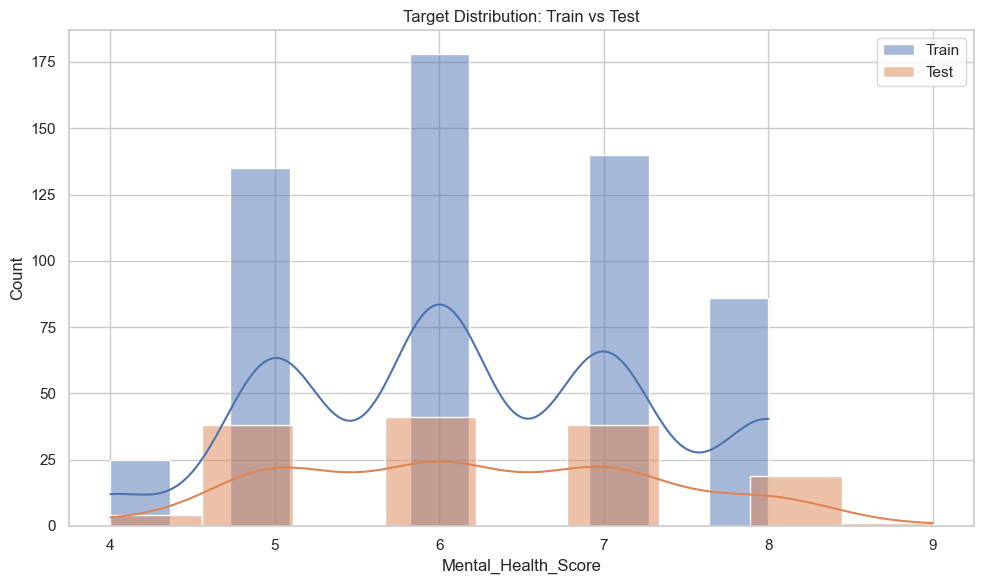

In [25]:
sns.histplot(y_train, kde=True, label="Train",alpha=0.5)
sns.histplot(y_test, kde=True, label="Test",alpha=0.5)
plt.legend()
plt.title("Target Distribution: Train vs Test")
plt.show()
# Зачем нужно?
# 1. Распределение таргета в train и test
# 2. Нет случайного перекоса
# 3. test не "другой природы"

The train-test split appears well-balanced.
The target distribution is consistent across both subsets, with nearly identical mean values and similar density structure.
This supports the validity of out-of-sample evaluation.

In [26]:
# ------------
# - Baseline -
# ------------
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
evaluate_regression(y_test, baseline_pred, label="Baseline")
# Вспомогательная функция показывает среднюю квадратическую ошибку 
# и сравнивает модель с предсказанием среднего

Baseline Performance
RMSE: 1.10
R^2: -0.000


In [27]:
# -------------
# - Model Fit - 
# -------------

model = LinearRegression()
model.fit(x_train, y_train)

y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

evaluate_regression(y_train, y_pred_train, label="Train")
evaluate_regression(y_test, y_pred_test, label="Test")
# Получили, что модель стала точнее примерно на 40%
# R^2 = 0.639 на тестовых данных показывает, что модель объясняет 64% вариации
# признака Avg_Daily_Usage_Hours только за счет двух переменных Avg_Daily_Usage_Hours
# и Sleep_Hours_Per_Night

Train Performance
RMSE: 0.65
R^2: 0.660
Test Performance
RMSE: 0.66
R^2: 0.639


The baseline model, which predicts the mean mental health score for all observations, yielded an RMSE of 1.10 and an R² of approximately 0, indicating no explanatory power beyond the sample mean.

In contrast, the linear regression model including daily social media usage and sleep duration significantly improved performance. On the training set, the model achieved an RMSE of 0.65 and an R² of 0.66. On the test set, performance remained stable, with an RMSE of 0.66 and an R² of 0.639.

This represents a substantial reduction in prediction error relative to the baseline model (approximately 40% improvement in RMSE) and indicates that behavioral intensity variables jointly explain nearly two-thirds of the variation in mental health scores.

Importantly, the similarity between training and testing performance suggests that the model generalizes well and does not exhibit signs of overfitting.

In [ ]:
# ----------------
# - Coefficients -
# ----------------

coef_df = pd.Series(model.coef_, index=features_baseline)
coef_df
# То есть при увеличении среднего времени в соцсетях 
# ментальное здоровье уменьшается примерно на 0.57 балла
# А при увеличении сна на 1 час и фиксированном времни в соцсетях
# ментальное здоровье растет на 0.18 балла 

Avg_Daily_Usage_Hours   -0.57
Sleep_Hours_Per_Night    0.18
dtype: float64

In [29]:
print(f"Intercept: {model.intercept_}")

Intercept: 7.825386963425276


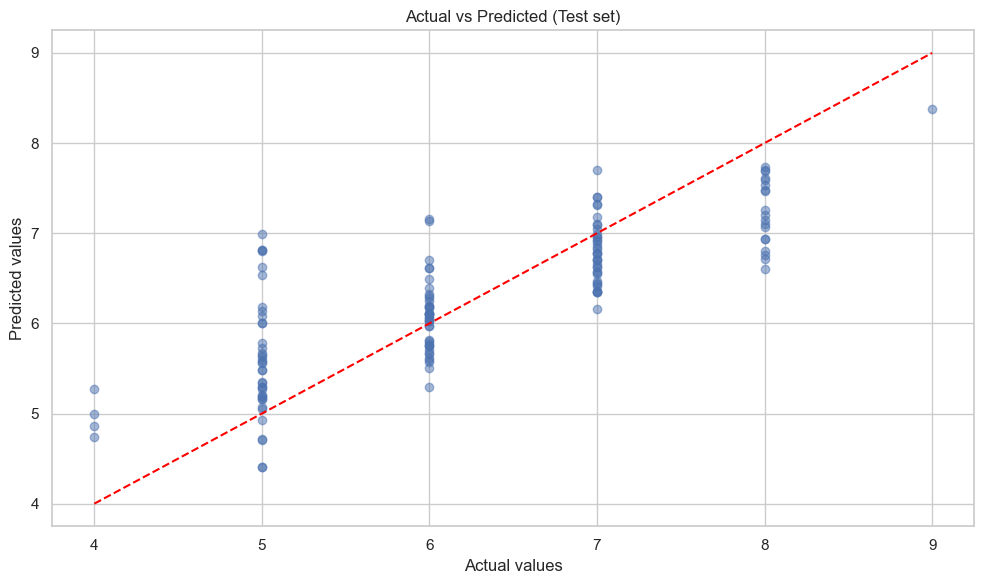

In [30]:
# ---------------
# - Diagnostics -
# ---------------

plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="red",
        linestyle="--"
        )

plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted (Test set)")
plt.show()
# Все точки лежат вдоль диагонали, нет никаких выбросов или изгибов

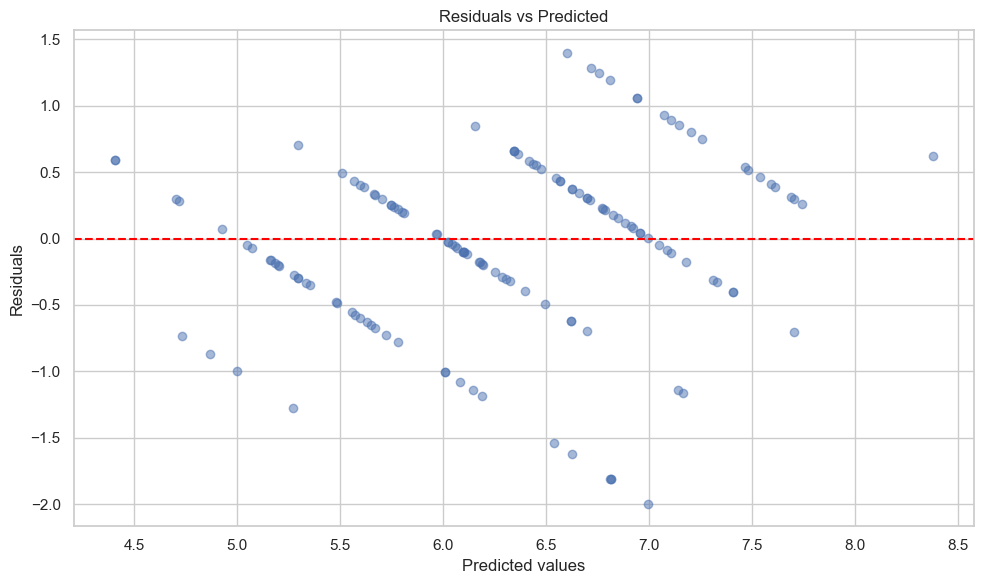

In [31]:
residuals_test = residuals(y_test, y_pred_test)

plt.scatter(y_pred_test, residuals_test, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()
# Остатки распределены вокруг нуля, не явной дуги, структуры тоже не наблюдается

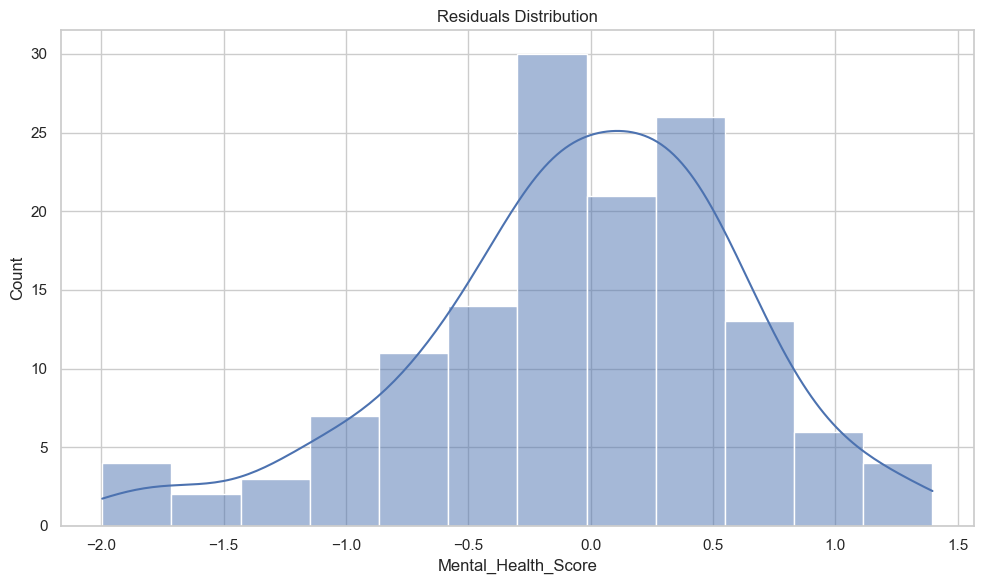

In [32]:
sns.histplot(residuals_test, kde=True)
plt.title("Residuals Distribution")
plt.show()
# Есть небольшой перекос, но в целом расперделение похоже на нормальное, 
# оно относительно симметрично

The regression coefficients confirm the behavioral interpretation suggested by the statistical analysis. Daily social media usage demonstrates a substantial negative effect (−0.57), indicating that increased usage is strongly associated with lower mental health scores, holding sleep duration constant. Sleep duration retains a positive but more moderate effect (+0.18), suggesting an independent yet smaller contribution.

The comparison between baseline and regression performance shows a substantial improvement in explanatory power, with the model explaining approximately 64% of the variance in mental health scores. The close alignment between training and testing performance indicates strong generalization and absence of overfitting.

Diagnostic plots further support model adequacy. The actual versus predicted plot shows close alignment along the diagonal, with no systematic curvature. The residuals appear randomly distributed around zero, with no visible structural pattern or strong heteroskedasticity. The residual distribution is approximately symmetric and centered at zero, suggesting that model errors are well-behaved.

Overall, the linear regression specification appears appropriate for capturing the relationship between behavioral intensity factors and mental health in this dataset.

## Extension of the Model Specification

While the baseline behavioral model demonstrated strong explanatory performance, the addiction score exhibited an extremely strong pairwise association with mental health.

To assess whether this relationship reflects independent explanatory power or conceptual overlap, the model is extended to include the addiction variable.

The purpose of this extension is to:

- Evaluate whether behavioral usage effects remain significant when addiction is controlled for;

- Assess the incremental explanatory power of the addiction score;

- Examine potential multicollinearity effects;

- Compare model stability and interpretability across specifications.

In [33]:
# ------------------
# - Extended Model -
# ------------------

# В этом случае на не нужен будет такой подробный анализ модели, как в базовом случае.
# Extended-версия строиться для сравнения.

# -----------------------
# - Variable Definition -
# -----------------------

features_extended = [
  "Avg_Daily_Usage_Hours",
  "Sleep_Hours_Per_Night",
  "Addicted_Score"
]

x_ext = df[features_extended]
y = df[target]

In [34]:
# --------------------
# - Train/Test Split -
# --------------------

x_train_ext, x_test_ext, y_train_ext, y_test_ext = train_test_split(
  x_ext,
  y,
  test_size=0.2,
  random_state=RANDOM_STATE
)

In [35]:
# -------------
# - Model Fit - 
# -------------

model_ext = LinearRegression()
model_ext.fit(x_train_ext, y_train_ext)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
# -------------
# - Metrics - 
# -------------

y_pred_train_ext = model_ext.predict(x_train_ext)
y_pred_test_ext = model_ext.predict(x_test_ext)

evaluate_regression(y_train_ext, y_pred_train_ext, label="Train")
evaluate_regression(y_test_ext, y_pred_test_ext, label="Test")

Train Performance
RMSE: 0.36
R^2: 0.896
Test Performance
RMSE: 0.36
R^2: 0.894


In [37]:
# ----------------
# - Coefficients -
# ----------------

coef_ext = pd.Series(model_ext.coef_, index=features_extended)
coef_ext

Avg_Daily_Usage_Hours   -0.08
Sleep_Hours_Per_Night   -0.06
Addicted_Score          -0.64
dtype: float64

In [38]:
print(f"Intercept: {model_ext.intercept_}")

Intercept: 11.193151490621055


## Comparative Model Interpretation

The extended model demonstrates a substantial increase in explanatory power (R² ≈ 0.89), largely driven by the inclusion of the addiction score. The addiction coefficient (−0.64) dominates the specification, while the previously strong effect of daily social media usage decreases sharply (from −0.57 to −0.08). Sleep duration loses its positive effect and becomes negligible.

This pattern suggests that addiction captures much of the behavioral variance previously attributed to usage and sleep. The dramatic improvement in model fit likely reflects conceptual overlap between the addiction scale and the mental health score rather than the discovery of an independent explanatory mechanism.

While the extended model achieves higher predictive performance, the baseline behavioral model provides clearer interpretability and more distinct insight into independent behavioral factors.

## Final Conclusion

This stage of the analysis transitioned from statistical association to multivariate regression modeling in order to quantify the joint influence of behavioral factors on students’ mental health scores.

The baseline behavioral model, including daily social media usage and sleep duration, demonstrated strong explanatory performance, accounting for approximately 64% of the variance in mental health scores. The model showed stable out-of-sample performance, no evidence of overfitting, and well-behaved residual structure. Importantly, daily social media usage exhibited a substantial negative effect, while sleep duration showed a smaller but positive contribution when controlling for usage.

An extended specification including the addiction score significantly increased predictive accuracy (R² ≈ 0.89). However, this improvement was accompanied by a sharp reduction in the independent effects of usage and sleep. The addiction variable dominated the model, suggesting strong conceptual overlap with the mental health score.

Thus, while the extended model achieved higher predictive performance, the baseline behavioral model provides clearer interpretability and more meaningful insight into independent behavioral determinants. This distinction highlights the fundamental difference between explanatory and predictive modeling approaches.

Overall, the regression analysis confirms that behavioral intensity factors play a substantial role in explaining mental health variation, while also demonstrating the importance of careful variable selection and conceptual validity in multivariate modeling.